In [1]:
from util.util import *
from util.param import *
from util.util import *
from util.util_montage import *

In [2]:
debug = False

In [3]:
# Hardcoded path for easier running
folder_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/data" # The data is stored here (.../condensate and .../RNA w/ ... being dataset subfolders)
img_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/result/img" # Images are saved here
result_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/result" # Calculation results are stored here

os.makedirs(img_path, exist_ok=True)

# Look up all subfolders in the data folder
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir() and not f.name.startswith('.')]
subfolders.sort()  # Sort the subfolders alphabetically

print(f"Found {len(subfolders)} subfolders in the data folder.")
i = 0
for subfolder in subfolders:
    print(f"    {i}: {subfolder.split('/')[-1]}")
    i += 1

Found 10 subfolders in the data folder.
    0: 2x_4EGI1
    1: 2x_CHX
    2: 2x_Har
    3: 2x_puro
    4: THOR_1x
    5: THOR_2x
    6: THORdel_2x
    7: THORdelta_1x
    8: mRNA-1x
    9: mRNA_2x


In [4]:
# Change this index to select different subfolders
index = 9
legend_bool = True

data_path = subfolders[index]
data_name = data_path.split("/")[-1]
print(f"Selected data for {data_name} in folder: {data_path}")

Selected data for mRNA_2x in folder: /Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/data/mRNA_2x


In [5]:
file_pairs = find_matching_files(data_path)

if not file_pairs:
    if debug:
        print("❌ No matching file pairs found!")
    pass
else:
    if debug:
        print(f"📂 Loading {len(file_pairs)} experiment datasets...")
    
    all_tracks = []
    all_condensates = []
    
    for rna_path, condensate_path, exp_name in track(file_pairs, description="Loading datasets"):
        df_tracks, df_condensates = load_dataset_pair(rna_path, condensate_path, exp_name)
        
        if df_tracks is not None and df_condensates is not None:
            all_tracks.append(df_tracks)
            all_condensates.append(df_condensates)
    
    if all_tracks and all_condensates:
        # Combine all datasets
        df_tracks_combined = pd.concat(all_tracks, ignore_index=True)
        df_condensates_combined = pd.concat(all_condensates, ignore_index=True)

        if debug:
            print(f"✅ Successfully loaded and combined:")
            print(f"   - {len(df_tracks_combined)} total track points")
            print(f"   - {len(df_condensates_combined)} total condensate entries")
            print(f"   - {df_tracks_combined['experiment'].nunique()} experiments")

        # Display summary statistics
        if debug:
            print("\n📊 Dataset Summary:")
        for exp in df_tracks_combined['experiment'].unique():
            exp_tracks = df_tracks_combined[df_tracks_combined['experiment'] == exp]
            exp_condensates = df_condensates_combined[df_condensates_combined['experiment'] == exp]
            if debug:
                print(f"   {exp}: {exp_tracks['trackID'].nunique()} tracks, "
                      f"{len(exp_condensates)} condensate entries")
    else:
        if debug:
            print("❌ No valid datasets were loaded successfully")
        pass

if debug:
    print("\n🎉 Data loading complete!")

Output()

## Minimum distance calculation from RNA to the boundary of condensates

In [6]:
print("🔄 Calculating distances from RNA to condensate boundaries...")

from shapely.geometry import Point, Polygon
from shapely.strtree import STRtree

### Optimized distance calculation using spatial index
output_csv = os.path.join(result_path, f"{data_name}_rna_condensate_distances.csv")

def calculate_rna_condensate_distances(df_tracks_combined, df_condensates_combined, output_csv, um_per_pixel, s_per_frame):
    """
    Calculates the signed distance from RNA tracks to the nearest condensate boundary.
    If a track point is found inside a condensate, it "locks" to that condensate for subsequent frames.

    Args:
        df_tracks_combined (pd.DataFrame): DataFrame with combined track data.
        df_condensates_combined (pd.DataFrame): DataFrame with combined condensate data.
        output_csv (str): Path to save the output CSV file.
        um_per_pixel (float): Conversion factor from pixels to micrometers.
        s_per_frame (float): Conversion factor from frames to seconds.

    Returns:
        pd.DataFrame: DataFrame with calculated distances.
    """
    # Check if output CSV already exists
    if os.path.exists(output_csv):
        print(f"⚠️ Output CSV '{output_csv}' already exists. Skipping distance calculation to avoid overwriting.")
        return pd.read_csv(output_csv)

    if df_tracks_combined.empty or df_condensates_combined.empty:
        print("❌ Combined datasets are empty. Skipping distance calculation.")
        return pd.DataFrame()

    records = []
    # Process each experiment separately
    unique_experiments = df_tracks_combined['experiment'].unique()
    print(f"  • Found {len(unique_experiments)} unique experiments to process.")
    
    for exp_idx, exp in enumerate(unique_experiments):
        print(f"  • Processing experiment: {exp} ({exp_idx + 1}/{len(unique_experiments)})")
        
        # Filter data for the current experiment
        condensates_exp = df_condensates_combined[df_condensates_combined['experiment'] == exp]
        tracks_exp = df_tracks_combined[df_tracks_combined['experiment'] == exp]

        # Pre-process condensates for all frames in the experiment
        condensates_by_frame = {}
        for frame, group in condensates_exp.groupby('frame'):
            shapely_polygons = []
            for cnt_str in group['contour_coord']:
                bx, by = parse_contour_string(cnt_str)
                if len(bx) >= 3:
                    poly = Polygon(zip(bx, by))
                    if not poly.is_valid:
                        poly = poly.buffer(0)
                    if not poly.is_empty:
                        shapely_polygons.append(poly)
            
            if shapely_polygons:
                condensates_by_frame[frame] = {
                    'polygons': shapely_polygons,
                    'index': STRtree(shapely_polygons)
                }

        # Group tracks by trackID
        tracks_by_id = tracks_exp.groupby('trackID')

        # Iterate through each track in the experiment
        for track_id, track_df in tqdm(tracks_by_id, desc=f"    ↳ Tracks in {exp}"):
            locked_condensate = None # Initialize locked condensate as None
            
            # Sort track by time
            track_df = track_df.sort_values('t')

            for _, row in track_df.iterrows():
                frame = row['t']
                point = Point(row['x'], row['y'])
                min_dist = np.nan
                
                # If locked, calculate distance to the locked condensate
                if locked_condensate is not None:
                    # Check if the locked condensate still exists in the current frame
                    # This simple check assumes condensate identity is maintained by location.
                    # A more robust method would need condensate tracking.
                    if frame in condensates_by_frame:
                        spatial_index = condensates_by_frame[frame]['index']
                        polygons = condensates_by_frame[frame]['polygons']
                        
                        nearest_poly_idx = spatial_index.nearest(point)
                        if nearest_poly_idx is not None:
                            candidate_poly = polygons[nearest_poly_idx]
                            if candidate_poly.distance(locked_condensate) <= 2: # 2 frames tolerance
                                locked_condensate = candidate_poly # Update to current frame's polygon

                    min_dist = point.distance(locked_condensate.boundary)
                    if locked_condensate.contains(point):
                        min_dist = -min_dist

                else: # If locked condensate is None
                    # If not locked, find the nearest condensate
                    if frame in condensates_by_frame:
                        spatial_index = condensates_by_frame[frame]['index']
                        polygons = condensates_by_frame[frame]['polygons']
                        nearest_poly_idx = spatial_index.nearest(point)
                        if nearest_poly_idx is not None:
                            nearest_poly = polygons[nearest_poly_idx]
                            min_dist = point.distance(nearest_poly.boundary)
                            
                            if nearest_poly.contains(point):
                                min_dist = -min_dist
                                locked_condensate = nearest_poly # Lock onto this condensate

                if not np.isnan(min_dist):
                    dist_um = min_dist * um_per_pixel
                    records.append({
                        'experiment': exp,
                        'trackID': track_id,
                        't': frame * s_per_frame,
                        'distance_um': dist_um
                    })

    # Create DataFrame and save
    df_distances = pd.DataFrame(records)
    if not df_distances.empty:
        df_distances.to_csv(output_csv, index=False)
        print(f"✅ Saved distances to: {output_csv}")
    else:
        print("No records were generated, CSV not saved.")
        
    return df_distances

# Call the function
df_distances = calculate_rna_condensate_distances(
    df_tracks_combined, 
    df_condensates_combined, 
    output_csv, 
    um_per_pixel, 
    s_per_frame
)

print("🔄 Generating distance vs. time plots...")

# Load distances if not in memory
try:
    df_distances = df_distances
except NameError:
    df_distances = pd.read_csv(os.path.join(result_path, "rna_condensate_distances.csv"))

# Identify first dwell per track per experiment
first_dwell = df_distances[df_distances['distance_um'] == 0] \
    .groupby(['experiment', 'trackID'])['t'] \
    .min() \
    .reset_index() \
    .rename(columns={'t': 't_dwell'})

print(f"  • Found {len(first_dwell)} first-dwell events across all experiments")

# Merge dwell times back into distances
df_plot = df_distances.merge(first_dwell, on=['experiment', 'trackID'], how='left')

# Keep only points at and after first dwell
df_plot = df_plot[df_plot['t'] >= df_plot['t_dwell']]

print("🔄 Generating distance vs. time plots for each experiment...")

# Load distances if not in memory
try:
    df_distances = df_distances
except NameError:
    df_distances = pd.read_csv(os.path.join(result_path, "rna_condensate_distances.csv"))

# Identify first dwell per track per experiment
first_dwell = df_distances[df_distances['distance_um'] <= 0] \
    .groupby(['experiment', 'trackID'])['t'] \
    .min() \
    .reset_index() \
    .rename(columns={'t': 't_dwell'})

print(f"  • Found {len(first_dwell)} first-dwell events across all experiments")

# Merge dwell times back into distances
df_plot = df_distances.merge(first_dwell, on=['experiment', 'trackID'], how='left')
# Keep only points at and after first dwell
df_plot = df_plot[df_plot['t'] >= df_plot['t_dwell']]

🔄 Calculating distances from RNA to condensate boundaries...
  • Found 1 unique experiments to process.
  • Processing experiment: 20220508-FLmRNA_2x_FOV-17 (1/1)


    ↳ Tracks in 20220508-FLmRNA_2x_FOV-17: 100%|██████████| 1469/1469 [00:05<00:00, 285.41it/s]


✅ Saved distances to: /Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/result/mRNA_2x_rna_condensate_distances.csv
🔄 Generating distance vs. time plots...
  • Found 6 first-dwell events across all experiments
🔄 Generating distance vs. time plots for each experiment...
  • Found 321 first-dwell events across all experiments


In [7]:
# Create separate plot for each experiment
experiments = df_plot['experiment'].unique()
print(f"  • Creating {len(experiments)} separate plots...")

from scipy.signal import find_peaks # For peak detection

df_filtered = pd.DataFrame()  # To collect tracks with peak detection errors
df_error = pd.DataFrame()  # To collect tracks with peak detection errors
df_outlier = pd.DataFrame()  # To collect tracks with peak detection errors

# Maximum jump per frame is 4 pixel frames 
max_jump = 3 * um_per_pixel / s_per_frame

error_count = 0
for exp in experiments:
    print(f"    → Processing experiment: {exp}")
    
    # Filter data for this experiment
    exp_data = df_plot[df_plot['experiment'] == exp]
    
    if exp_data.empty:
        print(f"      ⚠️ No dwell data found for {exp}, skipping...")
        continue
    
    # Create figure for this experiment
    fig, ax = plt.subplots(2, 1, figsize=(10, 14))
    
    track_count = 0
    # Plot each track in this experiment
    for track in np.sort(exp_data['trackID'].unique()):
        # if track_count >= 10:
            # print(f"      ⚠️ More than 10 tracks in {exp}, limiting to first 10 for clarity.")
            # break
        print(f"      • Plotting track {int(track)}...", end="\r")
        track_data = exp_data[exp_data['trackID'] == track]
        
        # Use find_peaks to highlight peaks with huge prominence
        x = np.array(track_data['t'] - track_data['t_dwell'])
        y = np.array(track_data['distance_um'])
        
        dx = np.diff(x)
        dy = np.diff(y)
        # Calculate derivative (dy/dx)
        derivative = dy / dx
        
        # Use find_peaks to highlight peaks with huge prominence
        try:
            peaks, _ = find_peaks(y,
                                  height=0.4, # only consider peaks above 0.4 um (arbitrary)
                                  prominence=0.7) # only consider peaks with at least 0.7 um prominence (arbitrary)
            # ax.plot(x[peaks], y[peaks], "x", color='red')
            # Continue to the next track if peak is found
            if len(peaks) >= 1:
                error_count += 1
                df_error = pd.concat([df_error, track_data], ignore_index=True)
                continue

        except Exception as e:
            print(f"      ❌ Error finding peaks for track {track} in {exp}: {e}")
            pass
        
        # Use different colors for better visibility
        ax[0].plot(x, y,
                alpha=0.5,
                linewidth=1.5,
                label=f"Track {int(track)}")

        ax[0].scatter(x, y,
                   s=10,
                   alpha=0.7,
                   zorder=10)

        # # Plot the derivative if it exists
        if 'derivative' in locals():
            ax[1].plot(x[:-1], derivative, alpha=0.5, linewidth=1.5, label=f"Track {int(track)}")
            
            if any(abs(derivative) > max_jump):
                df_outlier = pd.concat([df_outlier, track_data], ignore_index=True)
        
        df_filtered = pd.concat([df_filtered, track_data], ignore_index=True)
        track_count += 1
    
    ax[0].axhline(0, color='gray', linestyle='--', linewidth=1, zorder=12)
    
    ax[1].axhline(max_jump, color='orange', linestyle='--', linewidth=1, zorder=12)
    ax[1].axhline(-max_jump, color='orange', linestyle='--', linewidth=1, zorder=12)

    ax[0].set_xlabel("")
    ax[0].set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
    ax[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    
    ax[1].set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
    ax[1].set_ylabel("Distance Derivative (μm/s)", fontsize=12, fontweight='bold')
    
    
    ax[0].set_title(f"RNA Distance from Condensate Boundary Over Time\n{exp} ({track_count} tracks)", 
                fontsize=14, fontweight='bold')
    ax[0].grid(True, linestyle='--', alpha=0.3)

    # # Add legend with reasonable limit
    # max_legend_entries = 15
    # if track_count <= max_legend_entries:
    #     ax[0].legend(fontsize=9, ncol=2, loc='upper right', framealpha=0.9)
    # else:
    #     print(f"      ⚠️ Too many tracks ({track_count}) for legend in {exp}")
    
    # Add summary statistics as text box
    max_dist = exp_data['distance_um'].max()
    mean_dist = exp_data['distance_um'].mean()
    textstr = f'Max distance: {max_dist:.2f} μm\nMean distance: {mean_dist:.2f} μm'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    
    ax[0].text(0.02, 0.98, textstr, transform=ax[0].transAxes, fontsize=10, verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    
    # Save with experiment-specific filename
    safe_exp_name = exp.replace(" ", "_").replace("/", "_").replace("\\", "_")
    output_png = os.path.join(img_path, f"distance_vs_time_{safe_exp_name}.png")
    fig.savefig(output_png, dpi=300, bbox_inches='tight')
    print(f"      ✅ Saved: distance_vs_time_{safe_exp_name}.png")
    
    # plt.show()
    plt.close()  # Close to free memory

  • Creating 1 separate plots...
    → Processing experiment: 20220508-FLmRNA_2x_FOV-17
      ✅ Saved: distance_vs_time_20220508-FLmRNA_2x_FOV-17.png


In [8]:
# ### Added section to create a separate plot for tracks with peak detection errors
# # Create the plot for tracks with peak detection errors
# if not df_error.empty:
#     fig, ax = plt.subplots(figsize=(10, 7))
    
#     for exp in df_error['experiment'].unique():
#         exp_data = df_error[df_error['experiment'] == exp]
#         for track in exp_data['trackID'].unique():
#             track_data = exp_data[exp_data['trackID'] == track]
#             x = np.array(track_data['t'] - track_data['t_dwell'])
#             y = np.array(track_data['distance_um'])
#             ax.plot(x, y,
#                     alpha=0.5,
#                     linewidth=1.5)

#     ax.set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
#     ax.set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
#     ax.set_title(f"RNA Distance from Condensate Boundary Over Time\n(Tracks with Peak Detection Errors)", 
#                 fontsize=14, fontweight='bold')
#     ax.grid(True, linestyle='--', alpha=0.3)
    
#     plt.tight_layout()

#     # Use a safe experiment name for the error plot
#     error_exp_names = "_".join([str(e).replace(" ", "_").replace("/", "_").replace("\\", "_") for e in df_error['experiment'].unique()])
#     error_output_png_filename = f"peak_detection_errors_{error_exp_names}.png"
#     output_png = os.path.join(img_path, error_output_png_filename)
#     fig.savefig(output_png, dpi=300, bbox_inches='tight')
#     print(f"      ✅ Saved: {error_output_png_filename}")

#     # plt.show()
#     plt.close()  # Close to free memory

In [9]:
if not df_outlier.empty:
    n_outliers = df_outlier['trackID'].nunique()
    print(f"🔔 Found {n_outliers} tracks with outlier jumps exceeding {max_jump} μm.")

🔔 Found 16 tracks with outlier jumps exceeding 3.5100000000000002 μm.


In [10]:
# def plot_trajectory_snapshots(track_df,
#                               condensate_df,
#                               trace_df,
#                               t_max=3,
#                               title=None,
#                               save_path=None,
#                               um_per_pixel=0.1,     # Conversion factor
#                               window_size_um=5,     # Desired window size in micrometers
#                               scale_bar_um=1,       # Desired scale bar length in micrometers
#                               gradient_color=False
#                               ):   
#     """
#     Creates a single, zoomed-in snapshot for one RNA track interacting with one condensate.

#     This function is designed to plot a single interaction event, assuming the input
#     DataFrames are pre-filtered for one specific track and one specific condensate.

#     Parameters:
#     - df_tracks (pd.DataFrame): DataFrame containing the track data.
#     - exp_results (dict): A dictionary with metadata for the event.
#     - save_path (str): The full file path to save the snapshot.
#     - um_per_pixel (float): Conversion factor from micrometers to pixels.
#     - window_size_um (float): The fixed size of the square zoom window in micrometers.
#     - scale_bar_um (float): The length of the scale bar in micrometers.
#     """
#     # Parameters for the figure layout
#     window_size_px = window_size_um / um_per_pixel  # Convert window size to pixels

#     track_id = trace_df['trackID'].iloc[0]
#     experiment = trace_df['experiment'].iloc[0]

#     track_data = track_df[
#         (track_df['trackID'] == track_id)
#     ].sort_values('t')
    
#     if len(track_data) < 2:
#         print(f"⚠️ Track {track_id} has insufficient data points, skipping.")
#         return

#     # Use detect_RNA_condensate_interactions to find the condensate for each point
#     interaction_info = detect_RNA_condensate_interactions(track_data, condensate_df)

#     # Find the most frequently interacting condensate
#     if 'nearest_condensate_id' in interaction_info.columns and not interaction_info['nearest_condensate_id'].isnull().all():
#         most_common_condensate_id = interaction_info['nearest_condensate_id'].mode()[0]
        
#         # Find a frame where this condensate exists to get its contour
#         # We need to find the contour associated with this ID.
#         # The ID is per-frame, so we need to check frames where the track is present.
        
#         closest_condensate = None
#         for t in track_data['t'].unique():
#             frame_condensates = condensate_df[(condensate_df['experiment'] == experiment) & (condensate_df['frame'] == t)]
            
#             # Re-create condensate_id for this frame to match what detect_RNA_condensate_interactions did
#             if not frame_condensates.empty:
#                 frame_condensates = frame_condensates.copy()
#                 frame_condensates['condensate_id'] = range(len(frame_condensates))

#                 target_condensate = frame_condensates[frame_condensates['condensate_id'] == most_common_condensate_id]
                
#                 if not target_condensate.empty:
#                     contour_str = target_condensate.iloc[0]['contour_coord']
#                     cx, cy = parse_contour_string(contour_str)
#                     closest_condensate = (cx, cy)
#                     break # Found it, can stop searching frames
#     else:
#         closest_condensate = None

#     if closest_condensate is None:
#         print(f"⚠️ No condensate found for track {track_id}, skipping.")
#         return
    
#     cx, cy = closest_condensate
    
#     # Calculate the center of the combined bounding box of the track and condensate
#     min_x_cond, max_x_cond = np.min(cx), np.max(cx)
#     min_y_cond, max_y_cond = np.min(cy), np.max(cy)
    
#     min_x_track, max_x_track = track_data['x'].min(), track_data['x'].max()
#     min_y_track, max_y_track = track_data['y'].min(), track_data['y'].max()
    
#     center_x = (min(min_x_cond, min_x_track) + max(max_x_cond, max_x_track)) / 2
#     center_y = (min(min_y_cond, min_y_track) + max(max_y_cond, max_y_track)) / 2
    
#     # Set up a fixed-size zoom window in pixels
#     half_window_px = window_size_px / 2
#     zoom_xmin = int(center_x - half_window_px)
#     zoom_xmax = int(center_x + half_window_px)
#     zoom_ymin = int(center_y - half_window_px)
#     zoom_ymax = int(center_y + half_window_px)
    
#     if gradient_color:
#         color_map = plt.get_cmap('viridis')
#         max_time = track_data['t'].max() / 10  # Convert to seconds assuming 10 fps
#         num_points = int(max_time * 10)  # 10 fps for max_time seconds
#         frame_colors = [color_map(i / (num_points - 1)) for i in range(num_points)]
    
#     num_points_track = len(track_data)
#     num_points_trace = len(trace_df)
#     if num_points_track != num_points_trace:
#         print(f"⚠️ Mismatch in number of points: track_data has {num_points_track}, trace_df has {num_points_trace}")
    
#     # Create figure
#     fig, ax = plt.subplots(1, 2, figsize=(2*4, 4))
    
#     # Plot condensate boundary
#     ax[0].plot(cx, cy, lw=3, c="#2E86AB", alpha=0.9)
#     ax[0].plot([cx[-1], cx[0]], [cy[-1], cy[0]], c="#2E86AB", lw=3, alpha=0.9)
    
#     # Plot interacting track
#     if gradient_color:
#         num_points = len(track_data)
#         for i in range(num_points - 1):
#             frame = int(track_data['t'].iloc[i])
#             # Safeguard against index out of range
#             if frame < len(frame_colors):
#                 ax[0].plot(track_data['x'].iloc[i:i+2], track_data['y'].iloc[i:i+2], lw=2, c=frame_colors[frame-1], alpha=0.8)
#             else:
#                 # If frame is out of range, use the last available color
#                 ax[0].plot(track_data['x'].iloc[i:i+2], track_data['y'].iloc[i:i+2], lw=2, c=frame_colors[-1], alpha=0.8)
        
#         first_frame = int(track_data['t'].iloc[0])
#         final_frame = int(track_data['t'].iloc[-1])

#         if first_frame-1 < len(frame_colors) and final_frame-1 < len(frame_colors):
#             ax[0].plot(track_data.iloc[0]['x'], track_data.iloc[0]['y'], marker='o', markersize=6, color=frame_colors[first_frame-1], markerfacecolor='white', markeredgewidth=2)
#             ax[0].plot(track_data.iloc[-1]['x'], track_data.iloc[-1]['y'], marker='s', markersize=5, color=frame_colors[final_frame-1], markerfacecolor=frame_colors[final_frame-1], markeredgewidth=1, alpha=0.8)

#     else:
#         ax[0].plot(track_data['x'], track_data['y'], lw=2, c="#F24236", alpha=0.8)
#         ax[0].plot(track_data.iloc[0]['x'], track_data.iloc[0]['y'], marker='o', markersize=6, color="#D35400", markerfacecolor='white', markeredgewidth=2)
#         ax[0].plot(track_data.iloc[-1]['x'], track_data.iloc[-1]['y'], marker='s', markersize=5, color="#D35400", markerfacecolor="#D35400", markeredgewidth=1, alpha=0.8)
    
#     # Plot the trajectory after first dwell
#     first_dwell_time = trace_df['t_original'].iloc[0]
#     post_dwell_data = track_data[(track_data['t'] >= first_dwell_time * 10) & (track_data['t'] < (first_dwell_time + t_max) * 10)] # Convert to frame number assuming 10 fps

#     if gradient_color is False:
#         if not post_dwell_data.empty:
#             ax[0].plot(post_dwell_data['x'], post_dwell_data['y'], lw=2, c='tab:green', alpha=0.8, zorder=12)
#             ax[0].plot(post_dwell_data.iloc[0]['x'], post_dwell_data.iloc[0]['y'], marker='o', markersize=6, color='tab:green', markerfacecolor='white', markeredgewidth=2, zorder=13)
#             ax[0].plot(post_dwell_data.iloc[-1]['x'], post_dwell_data.iloc[-1]['y'], marker='s', markersize=5, color='tab:green', markerfacecolor='tab:blue', markeredgewidth=1, alpha=0.8, zorder=13)

#     # Add scale bar
#     scale_bar_length_px = scale_bar_um / um_per_pixel
#     scale_bar_x_start = zoom_xmax - (0.5 * window_size_px)  # Position 5% from left
#     scale_bar_y = zoom_ymin + (0.05 * window_size_px)   # Position 5% from top
#     ax[0].plot([scale_bar_x_start, scale_bar_x_start + scale_bar_length_px], [scale_bar_y, scale_bar_y], lw=7, c="black")

#     # Set zoom limitss
#     ax[0].set_xlim(zoom_xmin, zoom_xmax)
#     ax[0].set_ylim(zoom_ymin, zoom_ymax)
#     ax[0].set_aspect('equal', adjustable='box')
#     ax[0].axis('off')
    
    
#     # Plot the trajectory distance
#     if gradient_color:
#         color_map = plt.get_cmap('viridis')
#         num_points = len(trace_df)
#         for i in range(num_points - 1):
#             frame = int(trace_df['t'].iloc[i]*10)
#             # Safeguard against index out of range
#             if frame < len(frame_colors):
#                 ax[1].plot(trace_df['t'].iloc[i:i+2], trace_df['distance_um'].iloc[i:i+2], lw=2, c=frame_colors[frame-1], alpha=0.8)
#             else:
#                 # If frame is out of range, use the last available color
#                 ax[1].plot(trace_df['t'].iloc[i:i+2], trace_df['distance_um'].iloc[i:i+2], lw=2, c=frame_colors[-1], alpha=0.8)
#     else:
#         ax[1].plot(trace_df['t'], trace_df['distance_um'], lw=2, c='grey', alpha=0.8)
#     ax[1].set_xlabel("Time (s)", fontsize=12)
#     ax[1].set_ylabel("Distance (μm)", fontsize=12)
#     ax[1].tick_params(axis='both', which='major', labelsize=10)
#     ax[1].axhline(y=0, color='gray', linestyle='--', lw=1)
    
#     ax[1].set_xlim(0, 20)
#     ax[1].set_yticks(np.arange(-0.5, 0.6, 0.2))

#     if title is not None:
#         fig.suptitle(title, fontsize=16)

#     plt.tight_layout()
#     if save_path is not None:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
#     plt.show()

In [11]:
### Added section to create a separate plot for tracks with peak detection errors
# Create the plot for tracks with peak detection errors
if not df_outlier.empty:
    all_tracks = []
    for exp in df_outlier['experiment'].unique():
        exp_data = df_outlier[df_outlier['experiment'] == exp]
        for track in exp_data['trackID'].unique():
            all_tracks.append((exp, track))

    plot_count = 0
    for i in range(0, len(all_tracks), 50):
        plot_count += 1
        chunk_of_tracks = all_tracks[i:i + 50]
        
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Get unique experiment names for this chunk for the filename
        chunk_experiments = set()

        for exp, track_id in chunk_of_tracks:
            track_data = df_outlier[(df_outlier['experiment'] == exp) & (df_outlier['trackID'] == track_id)]
            x = np.array(track_data['t'] - track_data['t_dwell'])
            y = np.array(track_data['distance_um'])
            ax.plot(x, y, alpha=0.5, linewidth=1.5, label=f"Track {track_id}")
            chunk_experiments.add(exp)

        ax.set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
        ax.set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
        ax.set_title(f"RNA Distance from Condensate Boundary Over Time\n(Outlier Tracks, Part {plot_count})", 
                    fontsize=14, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        plt.tight_layout()

        # Create a safe filename for the plot
        error_exp_names = "_".join(sorted([str(e).replace(" ", "_").replace("/", "_").replace("\\", "_") for e in chunk_experiments]))
        
        # Make sure the outliers directory exists
        outlier_img_path = os.path.join(img_path, "outliers")
        os.makedirs(outlier_img_path, exist_ok=True)
        
        error_output_png_filename = f"outliers_{error_exp_names}_part_{plot_count}.png"
        output_png = os.path.join(outlier_img_path, error_output_png_filename)
        
        fig.savefig(output_png, dpi=300, bbox_inches='tight')
        print(f"      ✅ Saved: {error_output_png_filename}")

        plt.close()  # Close to free memory

      ✅ Saved: outliers_20220508-FLmRNA_2x_FOV-17_part_1.png


  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 0
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 766 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 128, trace_df has 28


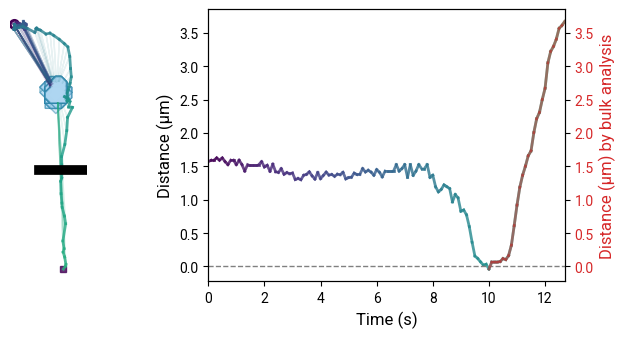

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_0.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 628
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 756 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 69, trace_df has 42


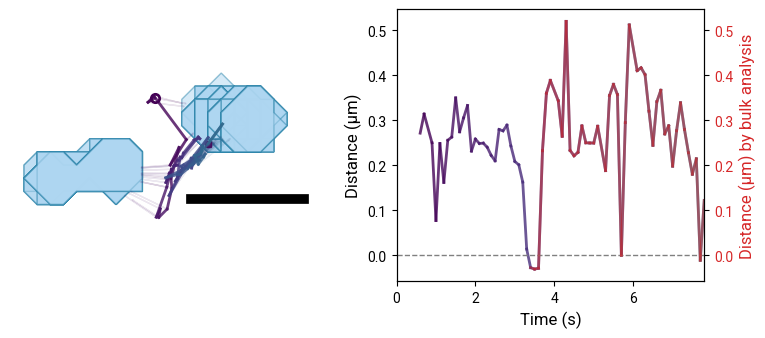

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_628.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 769
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 763 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 19, trace_df has 18


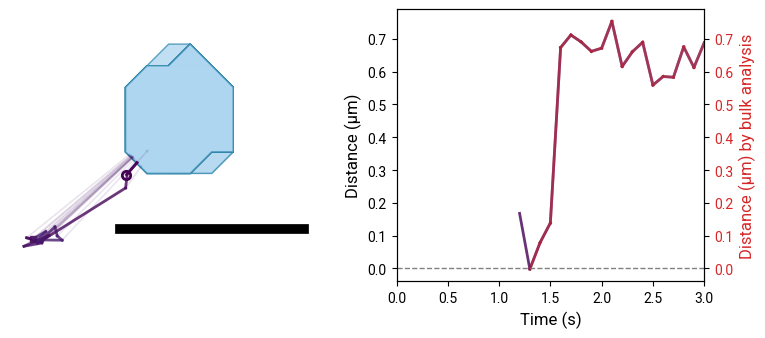

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_769.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 781
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 763 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 25, trace_df has 22


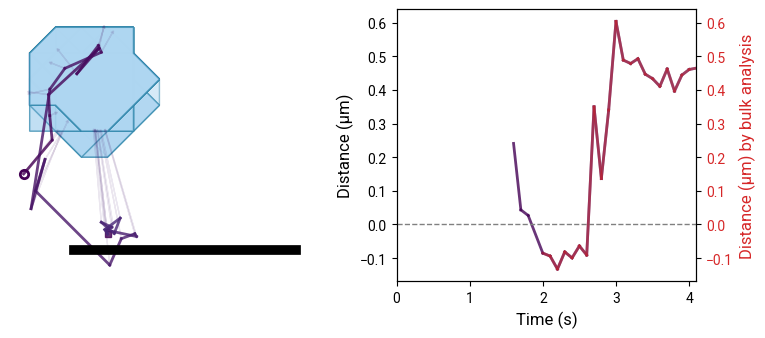

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_781.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 1043
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 765 condensates
Length of exp_results: 2


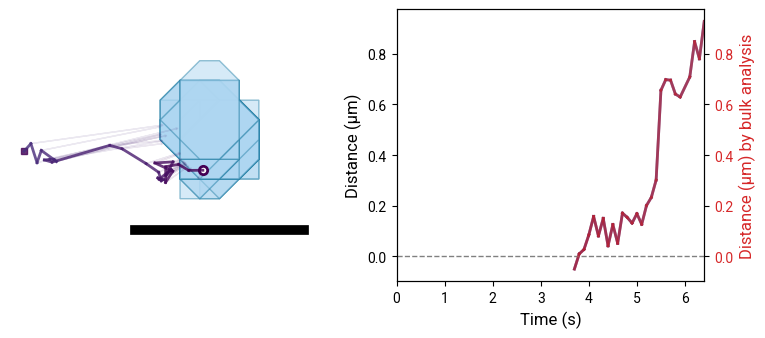

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_1043.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 1045
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 759 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 56, trace_df has 55


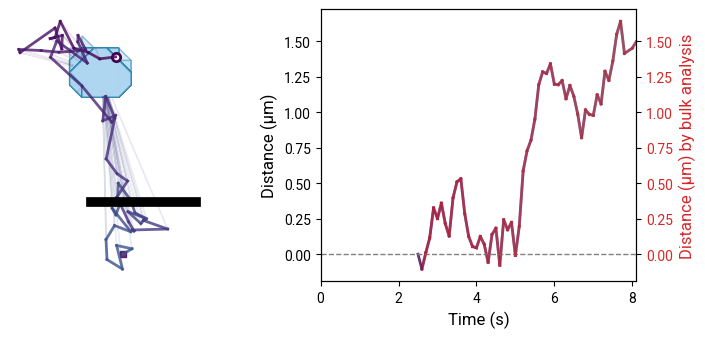

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_1045.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 1533
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 755 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 84, trace_df has 38


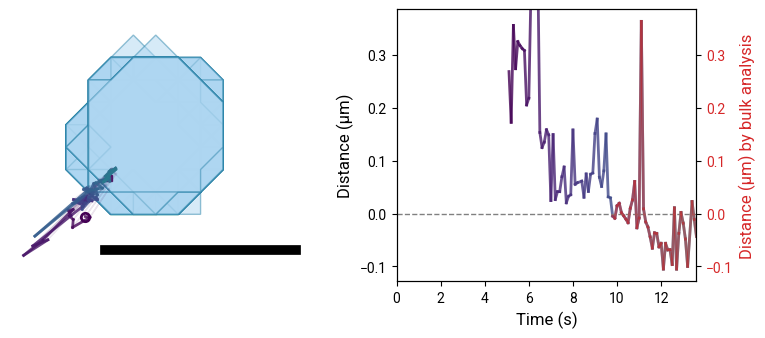

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_1533.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 1580
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 769 condensates
Length of exp_results: 2


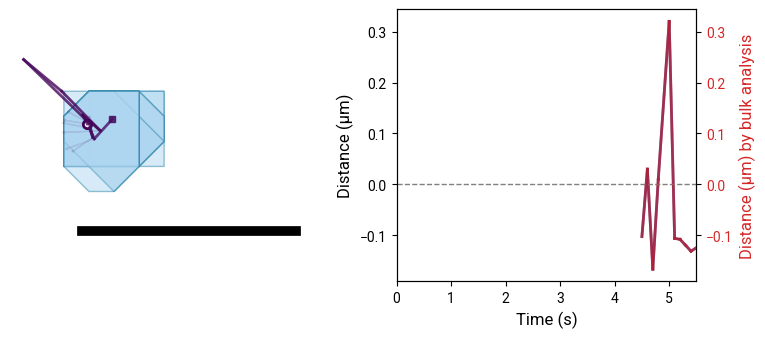

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_1580.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 1810
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 772 condensates
Length of exp_results: 2


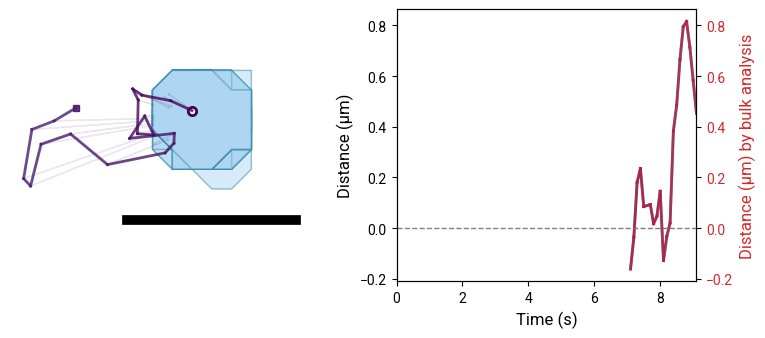

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_1810.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 2135
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 761 condensates
Length of exp_results: 2


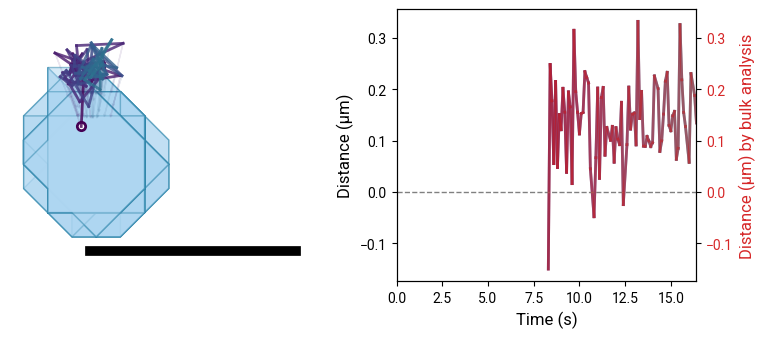

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_2135.png
🎉 Finished creating outlier snapshots.


In [12]:
# Plot the snapshot
# Create snapshots for outlier tracks
snapshot_save_path = os.path.join(img_path, "outliers", "snapshots")
os.makedirs(snapshot_save_path, exist_ok=True)

tracks_to_plot = all_tracks[0:10] # Limit to first 5 for testing

for exp, track_id in tracks_to_plot:
    print(f"  • Creating snapshot for outlier track: {exp}, Track ID: {track_id}")
    
    # Get the full track data from the combined dataframe
    track_df = df_tracks_combined[(df_tracks_combined['experiment'] == exp) & (df_tracks_combined['trackID'] == track_id)]
    
    # Get the condensate data for the experiment
    condensate_df = df_condensates_combined[df_condensates_combined['experiment'] == exp]
    
    # Get the outlier trace data
    trace_df = df_outlier[(df_outlier['experiment'] == exp) & (df_outlier['trackID'] == track_id)]
    
    if track_df.empty or condensate_df.empty or trace_df.empty:
        print(f"      ⚠️ Could not find all necessary data for outlier track {track_id} in {exp}. Skipping snapshot.")
        continue
        
    # Analyze interactions
    try:
        experiment_result = analyze_interactions(track_df, condensate_df, proximity_threshold=0)
    except Exception as e:
        print(f"      ❌ Error analyzing interactions for outlier track {track_id} in {exp}: {e}")
        continue

    # Create the snapshot
    # try:
    safe_exp_name = exp.replace(" ", "_").replace("/", "_").replace("\\", "_")
    snapshot_filename = f"snapshot_{safe_exp_name}_track_{track_id}.png"
    save_path = os.path.join(snapshot_save_path, snapshot_filename)
    plot_trajectory_snapshots(df_tracks=track_df,
                              df_condensates=condensate_df,
                              exp_results=experiment_result,
                              trace_df=trace_df,
                              window_size_um=1.0,
                              um_per_pixel=um_per_pixel,
                              gradient_color=True,
                              show_interaction=True,
                              show_condensate_movements=True,
                              distance_by_interaction=True,
                              save_path=save_path
                              )
    print(f"      ✅ Saved snapshot: {snapshot_filename}")
    # except Exception as e:
    #     print(f"      ❌ Error creating snapshot for outlier track {track_id} in {exp}: {e}")
        
print("🎉 Finished creating outlier snapshots.")

In [13]:
trace_df

,experiment,trackID,t,distance_um,t_dwell
260,20220508-FLmRNA_2x_FOV-17,2135,8.3,-0.150504,8.3
261,20220508-FLmRNA_2x_FOV-17,2135,8.4,0.248121,8.3
262,20220508-FLmRNA_2x_FOV-17,2135,8.5,0.177429,8.3
263,20220508-FLmRNA_2x_FOV-17,2135,8.6,0.055050,8.3
264,20220508-FLmRNA_2x_FOV-17,2135,8.7,0.215125,8.3
...,...,...,...,...,...
331,20220508-FLmRNA_2x_FOV-17,2135,15.8,0.127325,8.3
332,20220508-FLmRNA_2x_FOV-17,2135,16.0,0.057581,8.3
333,20220508-FLmRNA_2x_FOV-17,2135,16.1,0.230520,8.3
334,20220508-FLmRNA_2x_FOV-17,2135,16.3,0.187826,8.3


In [14]:
track_df

,trackID,t,x,y,displacement_um,n_steps,experiment
73471,2135,83,138.380868,477.561686,0.315885,76,20220508-FLmRNA_2x_FOV-17
73472,2135,84,138.514130,480.120691,0.315885,76,20220508-FLmRNA_2x_FOV-17
73473,2135,85,137.958354,480.102142,0.315885,76,20220508-FLmRNA_2x_FOV-17
73474,2135,86,138.464337,479.470516,0.315885,76,20220508-FLmRNA_2x_FOV-17
73475,2135,87,138.026152,480.559601,0.315885,76,20220508-FLmRNA_2x_FOV-17
...,...,...,...,...,...,...,...
73542,2135,158,139.158240,479.088249,0.315885,76,20220508-FLmRNA_2x_FOV-17
73543,2135,160,138.531389,479.492146,0.315885,76,20220508-FLmRNA_2x_FOV-17
73544,2135,161,139.639826,481.146536,0.315885,76,20220508-FLmRNA_2x_FOV-17
73545,2135,163,138.766605,479.605347,0.315885,76,20220508-FLmRNA_2x_FOV-17


In [15]:
experiment_result_df = pd.DataFrame(experiment_result)
experiment_result_df

,20220508-FLmRNA_2x_FOV-17
final_frame,164
contour_boundaries,"[([7, 6, 6, 6, 6, 7, 8, 9, 10, 10, 10, 9, 8], ..."
interacting_tracks,{2135}
total_tracks,1
total_condensates,761


In [16]:
exp, result = list(experiment_result.items())[0]
exp

'20220508-FLmRNA_2x_FOV-17'

In [17]:
experiment = list(experiment_result.keys())[0]
experiment

'20220508-FLmRNA_2x_FOV-17'

In [18]:
interacting_tracks = list(result['interacting_tracks'])
interacting_tracks

[2135]

In [19]:
track_id = interacting_tracks[0]
track_id

2135

In [20]:
final_frame = result['final_frame']
final_frame

164

In [21]:
track_data = track_df[
    (track_df['trackID'] == track_id) & 
    (track_df['t'] <= final_frame)].sort_values('t')

track_data

,trackID,t,x,y,displacement_um,n_steps,experiment
73471,2135,83,138.380868,477.561686,0.315885,76,20220508-FLmRNA_2x_FOV-17
73472,2135,84,138.514130,480.120691,0.315885,76,20220508-FLmRNA_2x_FOV-17
73473,2135,85,137.958354,480.102142,0.315885,76,20220508-FLmRNA_2x_FOV-17
73474,2135,86,138.464337,479.470516,0.315885,76,20220508-FLmRNA_2x_FOV-17
73475,2135,87,138.026152,480.559601,0.315885,76,20220508-FLmRNA_2x_FOV-17
...,...,...,...,...,...,...,...
73542,2135,158,139.158240,479.088249,0.315885,76,20220508-FLmRNA_2x_FOV-17
73543,2135,160,138.531389,479.492146,0.315885,76,20220508-FLmRNA_2x_FOV-17
73544,2135,161,139.639826,481.146536,0.315885,76,20220508-FLmRNA_2x_FOV-17
73545,2135,163,138.766605,479.605347,0.315885,76,20220508-FLmRNA_2x_FOV-17


In [22]:
interaction_info = detect_RNA_condensate_interactions(track_data, condensate_df[condensate_df['experiment'] == experiment])

In [23]:
interaction_info

,trackID,t,x,y,displacement_um,n_steps,experiment,min_distance_to_condensate,nearest_condensate_id,frame,is_interacting,shapely_contour,angle_to_contour,centroid_x,centroid_y
73471,2135,83,138.380868,477.561686,0.315885,76,20220508-FLmRNA_2x_FOV-17,-0.150504,217,83.0,True,"POLYGON ((138 473, 138 474, 137 475, 137 476, ...",-1.220785,138.380868,477.561686
73472,2135,84,138.514130,480.120691,0.315885,76,20220508-FLmRNA_2x_FOV-17,0.248121,215,84.0,True,"POLYGON ((137 474, 137 475, 137 476, 137 477, ...",-1.456483,138.514130,480.120691
73473,2135,85,137.958354,480.102142,0.315885,76,20220508-FLmRNA_2x_FOV-17,0.177429,213,85.0,True,"POLYGON ((139 473, 138 474, 137 475, 137 476, ...",-1.253294,137.958354,480.102142
73474,2135,86,138.464337,479.470516,0.315885,76,20220508-FLmRNA_2x_FOV-17,0.055050,213,86.0,True,"POLYGON ((139 473, 138 474, 137 475, 137 476, ...",-1.408036,138.464337,479.470516
73475,2135,87,138.026152,480.559601,0.315885,76,20220508-FLmRNA_2x_FOV-17,0.215125,210,87.0,True,"POLYGON ((138 474, 137 475, 137 476, 137 477, ...",-1.279084,138.026152,480.559601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73542,2135,158,139.158240,479.088249,0.315885,76,20220508-FLmRNA_2x_FOV-17,0.127325,219,158.0,True,"POLYGON ((138 473, 137 474, 137 475, 137 476, ...",-1.682879,139.158240,479.088249
73543,2135,160,138.531389,479.492146,0.315885,76,20220508-FLmRNA_2x_FOV-17,0.057581,215,160.0,True,"POLYGON ((137 474, 137 475, 136 476, 136 477, ...",-1.547607,138.531389,479.492146
73544,2135,161,139.639826,481.146536,0.315885,76,20220508-FLmRNA_2x_FOV-17,0.230520,213,161.0,True,"POLYGON ((137 474, 137 475, 136 476, 136 477, ...",-1.802843,139.639826,481.146536
73545,2135,163,138.766605,479.605347,0.315885,76,20220508-FLmRNA_2x_FOV-17,0.187826,214,163.0,True,"POLYGON ((137 474, 137 475, 137 476, 137 477, ...",-1.536892,138.766605,479.605347


In [24]:
contour = interaction_info['shapely_contour']
contour

73471    POLYGON ((138 473, 138 474, 137 475, 137 476, ...
73472    POLYGON ((137 474, 137 475, 137 476, 137 477, ...
73473    POLYGON ((139 473, 138 474, 137 475, 137 476, ...
73474    POLYGON ((139 473, 138 474, 137 475, 137 476, ...
73475    POLYGON ((138 474, 137 475, 137 476, 137 477, ...
                               ...                        
73542    POLYGON ((138 473, 137 474, 137 475, 137 476, ...
73543    POLYGON ((137 474, 137 475, 136 476, 136 477, ...
73544    POLYGON ((137 474, 137 475, 136 476, 136 477, ...
73545    POLYGON ((137 474, 137 475, 137 476, 137 477, ...
73546    POLYGON ((139 473, 138 474, 137 474, 137 475, ...
Name: shapely_contour, Length: 76, dtype: object

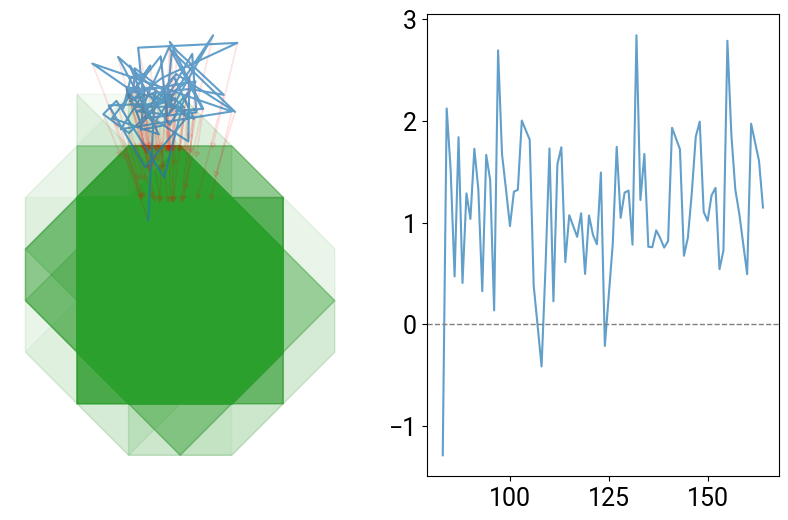

In [25]:
from matplotlib.patches import Polygon as MplPolygon
from shapely import wkt

# Plot the interaction info
x = interaction_info['x']
y = interaction_info['y']
distance_um = interaction_info['min_distance_to_condensate'] / um_per_pixel
angle = interaction_info['angle_to_contour']
contour = interaction_info['shapely_contour'] # Shapely Polygon objects

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].plot(x, y, color='tab:blue', alpha=0.7, label='RNA Track', zorder=12)

# Plot the distance with angle on the same plot
for i in range(len(x)-1):
    start_point = (x.iloc[i], y.iloc[i])
    dx = distance_um.iloc[i] * np.cos((angle.iloc[i]))
    dy = distance_um.iloc[i] * np.sin((angle.iloc[i]))
    end_point = (start_point[0] + dx, start_point[1] + dy)
    ax[0].arrow(start_point[0], start_point[1], end_point[0]-start_point[0], end_point[1]-start_point[1],
             head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.1)
    
    # Draw the condensate contour (Shapely Polygon)
    shapely_poly = contour.iloc[i]
        
    # Plot the filled polygon patch
    if isinstance(shapely_poly, str):
        shapely_poly = wkt.loads(shapely_poly)
    patch = MplPolygon(list(shapely_poly.exterior.coords), closed=True, color='tab:green', alpha=0.05, zorder=-1)
    ax[0].add_patch(patch)

# Remove spines for cleaner look
for spine in ax[0].spines.values():
    spine.set_visible(False)

ax[0].tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False)
ax[0].set_aspect('equal', adjustable='box')

ax[1].plot(interaction_info['t'], distance_um, color='tab:blue', alpha=0.7)
ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)

plt.show()

Plotting distance vs. time for verification: 20220508-FLmRNA_2x_FOV-17, Track ID: 0


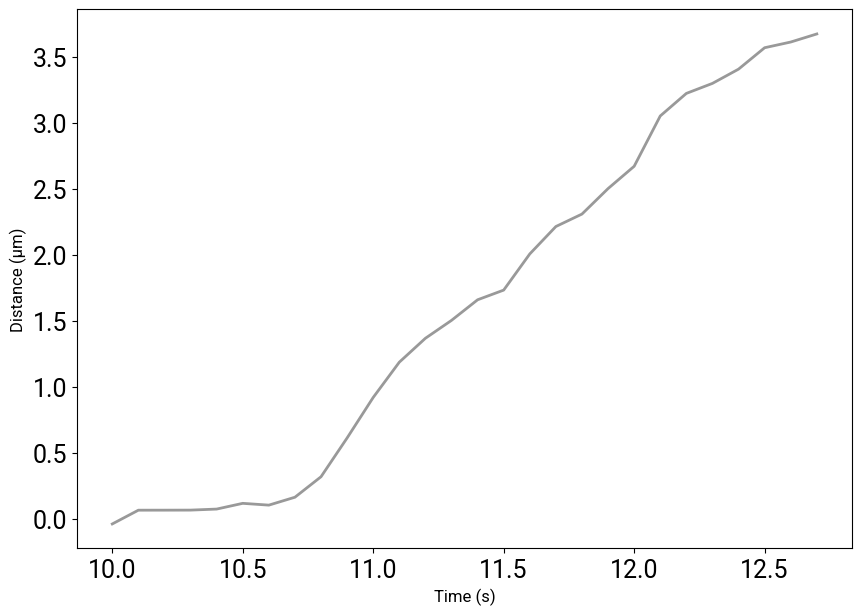

In [26]:
exp, track_id = all_tracks[0]
print(f"Plotting distance vs. time for verification: {exp}, Track ID: {track_id}")
snapshot_df_plot = df_plot[(df_plot['experiment'] == exp) & (df_plot['trackID'] == track_id)]

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(snapshot_df_plot['t'], snapshot_df_plot['distance_um'], lw=2, c='grey', alpha=0.8)
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Distance (μm)", fontsize=12)
plt.show()

In [27]:
first_interacting_condensate_id = interaction_info[interaction_info['is_interacting'] == True]['nearest_condensate_id'].iloc[0]
first_interacting_condensate_id

217

In [28]:
if not df_error.empty:
    all_tracks = []
    for exp in df_error['experiment'].unique():
        exp_data = df_error[df_error['experiment'] == exp]
        for track in exp_data['trackID'].unique():
            all_tracks.append((exp, track))

    plot_count = 0
    for i in range(0, len(all_tracks), 50):
        plot_count += 1
        chunk_of_tracks = all_tracks[i:i + 50]
        
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Get unique experiment names for this chunk for the filename
        chunk_experiments = set()

        for exp, track_id in chunk_of_tracks:
            track_data = df_error[(df_error['experiment'] == exp) & (df_error['trackID'] == track_id)]
            x = np.array(track_data['t'] - track_data['t_dwell'])
            y = np.array(track_data['distance_um'])
            ax.plot(x, y, alpha=0.5, linewidth=1.5, label=f"Track {track_id}")
            chunk_experiments.add(exp)

        ax.set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
        ax.set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
        ax.set_title(f"RNA Distance from Condensate Boundary Over Time\n(Tracks with Peak Detection Errors, Part {plot_count})", 
                    fontsize=14, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        plt.tight_layout()

        # Create a safe filename for the plot
        error_exp_names = "_".join(sorted([str(e).replace(" ", "_").replace("/", "_").replace("\\", "_") for e in chunk_experiments]))
        
        # Make sure the errors directory exists
        error_img_path = os.path.join(img_path, "errors")
        os.makedirs(error_img_path, exist_ok=True)
        
        error_output_png_filename = f"peak_detection_errors_{error_exp_names}_part_{plot_count}.png"
        output_png = os.path.join(error_img_path, error_output_png_filename)
        
        fig.savefig(output_png, dpi=300, bbox_inches='tight')
        print(f"      ✅ Saved: {error_output_png_filename}")

        plt.close()  # Close to free memory

      ✅ Saved: peak_detection_errors_20220508-FLmRNA_2x_FOV-17_part_1.png


In [35]:
# Save the filtered data into CSV files based on their types
experiments_list = df_filtered['experiment'].unique()
unique_exp_list = []
for exp in experiments_list:
    # Extract part before '_FOV' or '-FOV'
    if '_FOV' in exp:
        exp_str = exp.split('_FOV')[0]
    elif '-FOV' in exp:
        exp_str = exp.split('-FOV')[0]
    else:
        exp_str = exp

    unique_exp_list.append(exp_str)

unique_exp_list = list(set(unique_exp_list))

save_overwrite = True

for exp in unique_exp_list:
    print(f"  • Found unique experiment: {exp}")
    # Create a filtered DataFrame for the current experiment
    df_exp = df_filtered[df_filtered['experiment'].str.contains(exp)]
     
    # Save to CSV
    print(f"    → Saving data for experiment: {exp}")
    df_exp = df_filtered[df_filtered['experiment'].str.contains(exp)]
    # Remove 't_dwell' column to avoid confusion
    df_exp = df_exp.drop('t_dwell', axis=1)
    output_csv = os.path.join(result_path, f"{exp}.csv")

    # Check if csv already exists
    if os.path.exists(output_csv):
        if save_overwrite:
            df_exp.to_csv(output_csv, index=False)
        else:
            print(f"    ⚠️ File already exists, skipping: {output_csv}")
    else:
        df_exp.to_csv(output_csv, index=False)
    
df_filtered.to_csv(os.path.join(result_path, f"{data_name}_filtered_rna_condensate_distances.csv"), index=False)

print(f"Number of tracks with peak detection errors: {error_count} ({error_count/len(df_plot['trackID'].unique())*100:.1f}%)")

  • Found unique experiment: 20220508-FLmRNA_2x
    → Saving data for experiment: 20220508-FLmRNA_2x
Number of tracks with peak detection errors: 5 (1.6%)
